In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBRegressor


In [3]:
PROJECT_ROOT = Path.cwd().parents[1]
CSV_PATH = PROJECT_ROOT / Path("./data/ic50.csv").resolve()
print(CSV_PATH)

E:\Study\projects\coursework_classic_ml\data\ic50.csv


In [4]:
df = pd.read_csv(CSV_PATH)
df.head()

,"IC50, mM","CC50, mM",SI,MinAbsEStateIndex,MinPartialCharge,BCUT2D_MWHI,BCUT2D_CHGLO,BCUT2D_MRHI,BalabanJ,Chi2n,...,fr_diazo,fr_dihydropyridine,fr_isocyan,fr_isothiocyan,fr_lactam,fr_nitroso,fr_phos_acid,fr_phos_ester,fr_prisulfonamd,fr_thiocyan
0,-1.075459,-0.454784,1.126396,1.315234,1.389704,-0.731655,0.102992,-0.269909,-1.650186,1.584196,...,0,0,0,0,0,0,0,0,0,0
1,-1.817255,-1.858962,0.310663,1.698809,1.184451,-0.708822,-0.203884,-1.012282,-1.890085,1.721893,...,0,0,0,0,0,0,0,0,0,0
2,0.767548,-0.506936,-1.375902,1.717840,1.053951,-0.653210,-0.732509,-1.028518,-1.496762,2.341625,...,0,0,0,0,0,0,0,0,0,0
3,-1.594956,-0.737918,1.457668,1.326268,1.389704,-0.731812,0.104132,-0.269925,-1.773949,1.667404,...,0,0,0,0,0,0,0,0,0,0
4,0.371057,-0.593595,-0.975651,0.843212,1.739635,-0.730327,0.109185,-0.252916,-1.727728,1.934133,...,0,0,0,0,0,0,0,0,0,0


In [5]:
X_ic50 = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y_ic50 = df['IC50, mM']
X_train, X_test, y_train, y_test = train_test_split(X_ic50, y_ic50, test_size=0.1, random_state=42)


In [6]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)


In [7]:
print(r2_score(y_train, y_pred_train))
print(r2_score(y_test, y_pred_test))

0.8607566144280276
0.4845469902315297


In [8]:
print(mean_squared_error(y_train, y_pred_train))
print(mean_squared_error(y_test, y_pred_test))

0.13808320205864014
0.5482300141894058


<Axes: xlabel='importance', ylabel='feature'>

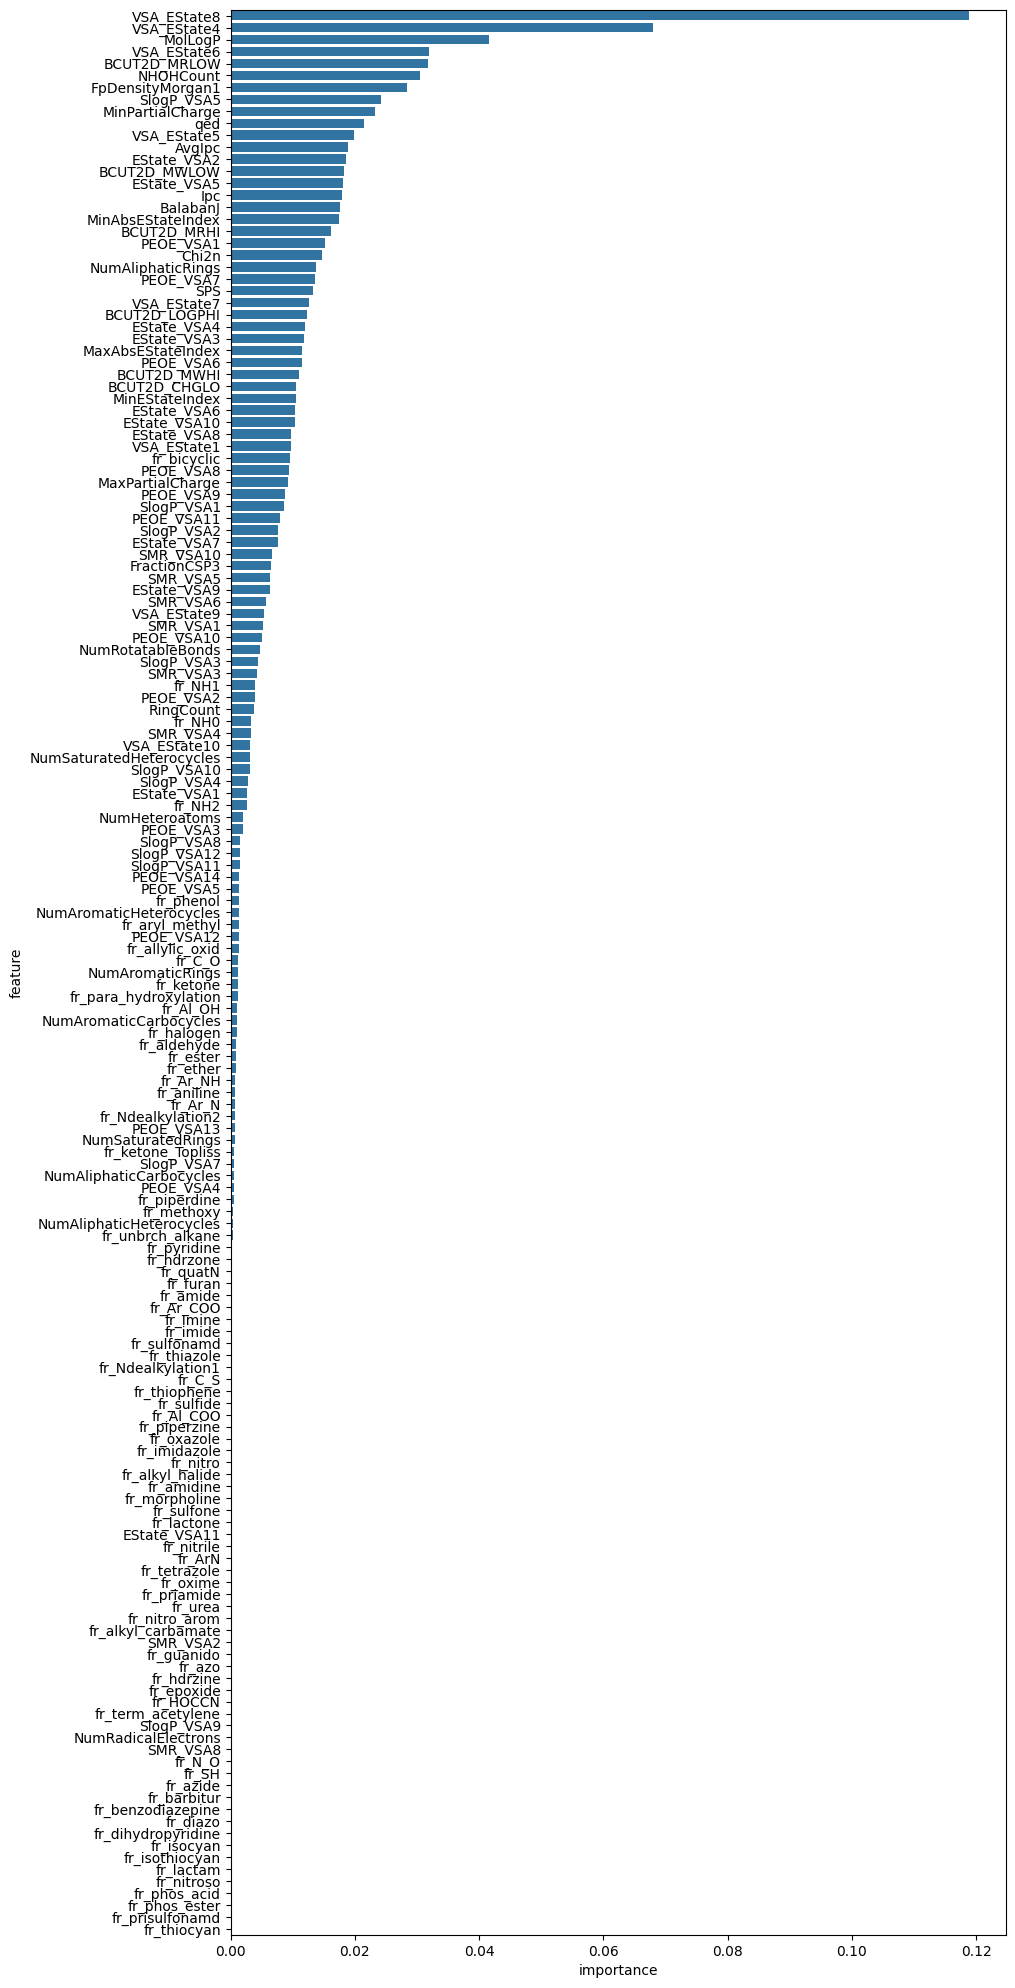

In [9]:
fi = rf.feature_importances_
df_fi = pd.DataFrame({'feature': X_ic50.columns, 'importance': fi})
df_fi = df_fi.sort_values(by='importance', ascending=False)
plt.figure(figsize=(10, 25))
sns.barplot(data=df_fi, x='importance', y='feature')

In [10]:
rfr = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 7, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': [0.5, 'sqrt', 'log2']
}

In [11]:
grid_search = GridSearchCV(
    estimator=rfr,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 324 candidates, totalling 972 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 7, 10, 15],
                         'max_features': [0.5, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2', verbose=1)

In [12]:
grid_search.best_score_

np.float64(0.4207743549597211)

In [13]:
print(grid_search.best_params_)

{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [14]:
xgb = XGBRegressor(random_state = 42, device="cuda", tree_method="hist")
# xgb.fit(X_train, y_train)
# xgb_pred_x_test = xgb.predict(X_test)
# xgb_pred_x_train = xgb.predict(X_train)

In [15]:
# print(r2_score(y_test, xgb_pred_x_test))
# print(r2_score(y_train, xgb_pred_x_train))

In [16]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 7, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1],
    'alpha': [0, 0.1, 1],
    'lambda': [1, 5, 10]
}

In [17]:
grid_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=1,
    verbose=1
)
grid_search_xgb.fit(X_train, y_train)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\arayd\anaconda3\envs\gpu_cuda\lib\site-packages\xgboost\core.py:158: UserWarning: [11:06:37] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device='cuda',
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rat...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None,
                                          random_state=42, ...),
                   n_jobs=1,
                   param_distributions={'alpha': [0, 0.1, 1],
                                        'colsample_bytree': [0.7, 0.8, 1],
                                        'lambda': [1, 5, 10],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 7, 10, 15],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1]},
                   scoring='r2', verbose=1)

In [18]:
grid_search_xgb.best_score_

np.float64(0.4049767440168548)

In [19]:
grid_search_xgb.best_params_

{'subsample': 0.8,
 'n_estimators': 300,
 'max_depth': 7,
 'learning_rate': 0.01,
 'lambda': 1,
 'colsample_bytree': 0.8,
 'alpha': 1}

In [20]:
grid_search_xgb_pred_x_test = grid_search_xgb.best_estimator_.predict(X_test)
grid_search_xgb_pred_x_train = grid_search_xgb.best_estimator_.predict(X_train)

In [21]:
print(r2_score(y_train, grid_search_xgb_pred_x_train))
print(r2_score(y_test, grid_search_xgb_pred_x_test))


0.8237431545492483
0.5122616413533576


In [22]:
print(mean_squared_error(y_train, grid_search_xgb_pred_x_train))
print(mean_squared_error(y_test, grid_search_xgb_pred_x_test))

0.17478826376291132
0.5187530234844743
